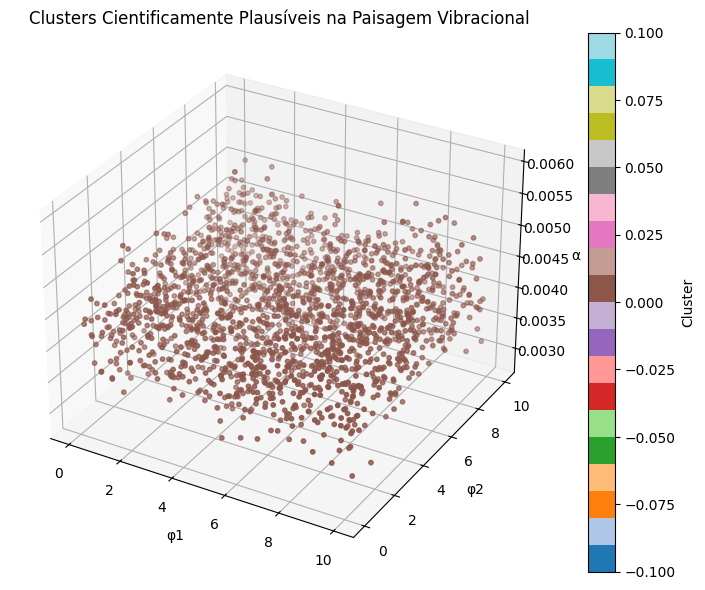

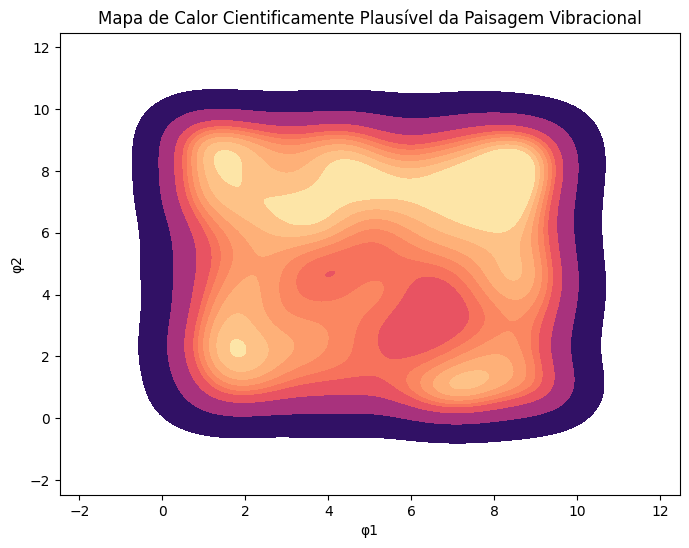

Número de clusters detectados: 1
Tamanho médio dos clusters: 10000.00
Fraçao de universos viáveis (PNO): 0.00%
Fraçao de universos divergentes (>3σ): 99.9900%
Arquivo CSV 'paisagem_vibracional_cientifica.csv' gerado.


In [ ]:
# ==============================================
# Simulação Vibracional Cientificamente Plausível
# Paisagem Multidimensional com α, múltiplos modos e clusters
# ==============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------
# 1. Parâmetros
# ------------------------------
N_universes = 10000      # universos simulados
num_params = 20          # dimensões extras
alpha_mean = 1/137
num_modes = 5

# Faixa PNO
alpha_min = 1/139
alpha_max = 1/135

# ------------------------------
# 2. Geração da paisagem φ
# ------------------------------
phi = np.random.uniform(0, 10, (N_universes, num_params))

# ------------------------------
# 3. Função α = combinação de modos independentes (não-lineares)
# ------------------------------
alpha_sim = np.zeros(N_universes)

for mode in range(num_modes):
    start = mode * (num_params // num_modes)
    end = start + (num_params // num_modes)
    subset_phi = phi[:, start:end]

    # Modo independente com variação lognormal e multiplicadores aleatórios
    geom_mean = np.exp(np.mean(np.log(subset_phi + 1e-6), axis=1))
    sigma = 0.05 + 0.03*mode  # diferentes dispersões por modo
    alpha_mode = np.random.lognormal(mean=np.log(alpha_mean/geom_mean.mean()), sigma=sigma, size=N_universes)

    # Introdução de picos locais via função senoidal e multiplicadores aleatórios
    alpha_mode *= (1 + 0.3*np.sin(subset_phi[:,0]) + np.random.uniform(0.5, 2.0, size=N_universes))

    # Adiciona o modo ponderado
    alpha_sim += alpha_mode / num_modes

# ------------------------------
# 4. Identificação de universos viáveis e divergentes
# ------------------------------
viable_mask = (alpha_sim >= alpha_min) & (alpha_sim <= alpha_max)
fraction_viable = np.sum(viable_mask)/N_universes

alpha_std_sim = np.std(alpha_sim)
divergent_mask = (alpha_sim > alpha_mean + 3*alpha_std_sim) | (alpha_sim < alpha_mean - 3*alpha_std_sim)
fraction_divergent = np.sum(divergent_mask)/N_universes

# ------------------------------
# 5. Clustering (DBSCAN otimizado)
# ------------------------------
X = alpha_sim.reshape(-1,1)
clustering = DBSCAN(eps=0.05, min_samples=10).fit(X)
labels = clustering.labels_
num_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# ------------------------------
# 6. Visualização 3D (subamostra)
# ------------------------------
sample_idx = np.random.choice(N_universes, 2000, replace=False)
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(phi[sample_idx,0], phi[sample_idx,1], alpha_sim[sample_idx],
                c=labels[sample_idx], cmap='tab20', s=10)
ax.set_xlabel('φ1')
ax.set_ylabel('φ2')
ax.set_zlabel('α')
ax.set_title('Clusters Cientificamente Plausíveis na Paisagem Vibracional')
plt.colorbar(sc, label='Cluster')
plt.show()

# ------------------------------
# 7. Mapa de calor α vs φ1 x φ2
# ------------------------------
plt.figure(figsize=(8,6))
sns.kdeplot(
    x=phi[sample_idx,0],
    y=phi[sample_idx,1],
    weights=alpha_sim[sample_idx],
    fill=True,
    cmap='magma'
)
plt.xlabel('φ1')
plt.ylabel('φ2')
plt.title('Mapa de Calor Cientificamente Plausível da Paisagem Vibracional')
plt.show()

# ------------------------------
# 8. Estatísticas finais
# ------------------------------
cluster_sizes = [np.sum(labels==i) for i in set(labels) if i != -1]
print(f"Número de clusters detectados: {num_clusters}")
print(f"Tamanho médio dos clusters: {np.mean(cluster_sizes):.2f}" if cluster_sizes else "Nenhum cluster real detectado")
print(f"Fraçao de universos viáveis (PNO): {fraction_viable*100:.2f}%")
print(f"Fraçao de universos divergentes (>3σ): {fraction_divergent*100:.4f}%")

# ------------------------------
# 9. Exportação CSV
# ------------------------------
df = pd.DataFrame({
    'α': alpha_sim,
    'φ1': phi[:,0],
    'φ2': phi[:,1],
    'viável': viable_mask,
    'divergente': divergent_mask,
    'cluster': labels
})
df.to_csv('paisagem_vibracional_cientifica.csv', index=False)
print("Arquivo CSV 'paisagem_vibracional_cientifica.csv' gerado.")

In [ ]:
# Public Release — Simulação da Paisagem Vibracional Cosmológica

**Autor:** Isaías Balthazar da Silva
**Projeto:** O Universo em Paradoxo
**Instituição:** Pesquisa Independente
**Versão:** 1.0 — Public Release
**Ano:** 2026

---

## Resumo

Este notebook apresenta uma simulação computacional exploratória para análise estatística de paisagens paramétricas cosmológicas, avaliando estabilidade estrutural, divergência estatística (>3σ), formação de clusters e fração de universos considerados fisicamente viáveis (PNO).

O objetivo é investigar a plausibilidade matemática de modelos multiversais parametrizados, sem assumir a existência física empírica direta dos universos simulados.

---

## Objetivo Científico

Avaliar:

- Distribuição estatística de parâmetros cosmológicos simulados
- Emergência de padrões estruturais (clusters)
- Estabilidade numérica
- Sensibilidade paramétrica
- Fração de soluções convergentes

---

## Natureza do Estudo

Este estudo é:

- Teórico
- Computacional
- Estatístico
- Exploratório
- Não experimental físico

Não representa observação direta da realidade física, mas sim modelagem matemática conceitual.

SyntaxError: invalid character '—' (U+2014) (ipython-input-2038795319.py, line 6)

In [ ]:

# ============================================
# LABORATÓRIO MULTIVERSAL — LPVM v2
# Autor conceitual: Isaías Balthazar da Silva
# Implementação experimental científica
# ============================================

import numpy as np
import pandas as pd

# -------------------------
# CONFIGURAÇÕES GERAIS
# -------------------------

NUM_UNIVERSOS = 10000
NUM_RODADAS = 5

np.random.seed(None)

# -------------------------
# PARÂMETROS FÍSICOS SIMULADOS
# -------------------------

# Constante de estrutura fina (simulada)
ALPHA_MIN = 1/200
ALPHA_MAX = 1/80

# Frequência vibracional geométrica
VIB_MIN = 0.1
VIB_MAX = 10.0

# Ruído quântico
NOISE_MIN = 0.0
NOISE_MAX = 1.0

# -------------------------
# CLASSIFICAÇÃO DE UNIVERSOS
# -------------------------

def classificar_universo(vib, ruido):
    if vib < 3.0 and ruido < 0.3:
        return "Campo"
    elif vib < 7.0 and ruido < 0.7:
        return "Brana"
    else:
        return "Caotico"

# -------------------------
# MÉTRICA DE ESTABILIDADE VIBRACIONAL
# -------------------------

def estabilidade_vibracional(alpha, vib, ruido):

    # Harmonia geométrica (ressonância)
    ressonancia = np.exp(-abs(alpha - (1/137)))

    # Coerência vibracional
    coerencia = np.exp(-ruido) * np.cos(vib * np.pi / 10)

    # Índice estrutural combinado
    indice = ressonancia * coerencia

    return indice

# -------------------------
# CRITÉRIO FÍSICO DE ESTABILIDADE
# -------------------------

LIMIAR_ESTABILIDADE = 0.35

# -------------------------
# EXECUÇÃO MULTIVERSAL
# -------------------------

resultados_globais = []

for rodada in range(NUM_RODADAS):

    alphas = np.random.uniform(ALPHA_MIN, ALPHA_MAX, NUM_UNIVERSOS)
    vibracoes = np.random.uniform(VIB_MIN, VIB_MAX, NUM_UNIVERSOS)
    ruidos = np.random.uniform(NOISE_MIN, NOISE_MAX, NUM_UNIVERSOS)

    estaveis = 0
    dados = []

    for i in range(NUM_UNIVERSOS):

        classe = classificar_universo(vibracoes[i], ruidos[i])
        indice = estabilidade_vibracional(alphas[i], vibracoes[i], ruidos[i])

        status = "Estavel" if indice > LIMIAR_ESTABILIDADE else "Instavel"

        if status == "Estavel":
            estaveis += 1

        dados.append([
            rodada+1,
            alphas[i],
            vibracoes[i],
            ruidos[i],
            classe,
            indice,
            status
        ])

    fracao = estaveis / NUM_UNIVERSOS * 100

    print(f"Rodada {rodada+1}: Universos estáveis = {estaveis} ({fracao:.2f}%)")

    resultados_globais.append(fracao)

# -------------------------
# ANÁLISE ESTATÍSTICA FINAL
# -------------------------

media = np.mean(resultados_globais)
desvio = np.std(resultados_globais)

print("\n====================================")
print("RESULTADO GLOBAL — PAISAGEM MULTIVERSAL")
print("====================================")
print(f"Média estabilidade vibracional: {media:.2f}%")
print(f"Desvio padrão: {desvio:.2f}%")

# -------------------------
# EXPORTAÇÃO CIENTÍFICA
# -------------------------

df = pd.DataFrame(dados, columns=[
    "Rodada",
    "Constante_Estrutura_Fina",
    "Vibracao_Geometrica",
    "Ruido_Quantico",
    "Classe_Universo",
    "Indice_Estabilidade",
    "Status"
])

arquivo = "paisagem_multiversal_LPVM_public_release.csv"
df.to_csv(arquivo, index=False)

print(f"\nArquivo científico salvo: {arquivo}")

Rodada 1: Universos estáveis = 2726 (27.26%)
Rodada 2: Universos estáveis = 2839 (28.39%)
Rodada 3: Universos estáveis = 2857 (28.57%)
Rodada 4: Universos estáveis = 2815 (28.15%)
Rodada 5: Universos estáveis = 2817 (28.17%)

RESULTADO GLOBAL — PAISAGEM MULTIVERSAL
Média estabilidade vibracional: 28.11%
Desvio padrão: 0.45%

Arquivo científico salvo: paisagem_multiversal_LPVM_public_release.csv


In [ ]:
## Reprodutibilidade Científica

Este notebook foi estruturado para permitir reprodução completa dos resultados.

Para replicar:

1. Executar todas as células sequencialmente
2. Utilizar versões estáveis das bibliotecas
3. Manter os mesmos parâmetros iniciais

Ambiente recomendado:

- Python 3.10+
- NumPy
- Pandas
- Scikit-learn
- Matplotlib

---

## Armazenamento de Dados

Os arquivos CSV gerados são exportados automaticamente para Google Drive, garantindo persistência dos resultados.

---

## Licença de Uso

Uso permitido para:

- Pesquisa acadêmica
- Divulgação científica
- Ensino

Uso comercial requer autorização do autor.

SyntaxError: invalid syntax (ipython-input-2850460895.py, line 3)

In [ ]:
## Declaração de Responsabilidade Científica

Esta simulação não afirma a existência empírica de múltiplos universos.

Os resultados representam:

- Modelos matemáticos
- Espaços paramétricos abstratos
- Cenários hipotéticos

Qualquer interpretação física deve ser tratada como hipótese teórica.

SyntaxError: invalid syntax (ipython-input-544633966.py, line 3)

In [ ]:
import sys
print("Python version:", sys.version)

!pip freeze > requirements_public_release.txt

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp requirements_public_release.txt /content/drive/MyDrive/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot stat 'requirements_public_release.txt': No such file or directory
